In [170]:
import math
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, Dataset
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import random
from tqdm import tqdm
import time
from torch.optim.lr_scheduler import ReduceLROnPlateau

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

**1. Загрузка датасетов. Первичный анализ**

In [171]:
print("Загружаем jester_ratings.csv...")
ratings_df = pd.read_csv('jester_ratings.csv')

print("Загружаем jester_items.csv...")
jokes_df = pd.read_csv('jester_items.csv')

print(f"\n Загрузка завершена!")
print(f"   Рейтинги: {ratings_df.shape[0]:,} строк, {ratings_df.shape[1]} столбцов")
print(f"   Шутки: {jokes_df.shape[0]:,} строк, {jokes_df.shape[1]} столбцов")

Загружаем jester_ratings.csv...
Загружаем jester_items.csv...

 Загрузка завершена!
   Рейтинги: 1,761,439 строк, 3 столбцов
   Шутки: 150 строк, 2 столбцов


Т.к. количество срок слишком большое стоит его сократить до 10000, чтобы сократить время выполнения

In [172]:
random.seed(42)
np.random.seed(42)

if ratings_df.shape[0] > 10000:
    sample_indices = np.random.choice(ratings_df.index, size=10000, replace=False)
    ratings_sample = ratings_df.loc[sample_indices].copy()
else:
    ratings_sample = ratings_df.copy()

print(f"Размер выборки после сокращения: {ratings_sample.shape[0]:,} строк")

Размер выборки после сокращения: 10,000 строк


In [173]:
print("\nПервые 5 строк рейтингов:")
print(ratings_df.head())


print("\nИнформация о таблице рейтингов:")
print(ratings_df.info())


print("\nПропущенные значения:")
print("Рейтинги:")
print(ratings_df.isnull().sum())
print('\n')
print(f"Количество явных дубликатов: {ratings_df.duplicated().sum()}\n")
print(f"userId вне диапазона (1-63978): {((ratings_df['userId'] < 1) | (ratings_df['userId'] > 63978)).sum()}")
print(f"jokeId вне диапазона (1-150): {((ratings_df['jokeId'] < 1) | (ratings_df['jokeId'] > 150)).sum()}")



Первые 5 строк рейтингов:
   userId  jokeId  rating
0       1       5   0.219
1       1       7  -9.281
2       1       8  -9.281
3       1      13  -6.781
4       1      15   0.875

Информация о таблице рейтингов:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1761439 entries, 0 to 1761438
Data columns (total 3 columns):
 #   Column  Dtype  
---  ------  -----  
 0   userId  int64  
 1   jokeId  int64  
 2   rating  float64
dtypes: float64(1), int64(2)
memory usage: 40.3 MB
None

Пропущенные значения:
Рейтинги:
userId    0
jokeId    0
rating    0
dtype: int64


Количество явных дубликатов: 0

userId вне диапазона (1-63978): 0
jokeId вне диапазона (1-150): 0


Из результатов видно, что пропущенных значений нет, т.е. все поля заполнены.  
Дубликатов также нет, все значения id в нужном диапазоне.  
Типы данных корректны: userId - int, jokeId - int, rating - float.  

In [174]:
print("Статистика рейтингов:")
print(ratings_df['rating'].describe())

print(f"\nДиапазон рейтингов:")
print(f"   Минимум: {ratings_df['rating'].min():.2f}")
print(f"   Максимум: {ratings_df['rating'].max():.2f}")

num_users = ratings_df['userId'].nunique()
num_jokes = ratings_df['jokeId'].nunique()
print(f"\nУникальныйе значения:")
print(f"   Пользователей: {num_users:,}")
print(f"   Шуток: {num_jokes:,}")

ratings_per_user = ratings_df.groupby('userId').size()
print(f"\nСтатистика пользователей:")
print(f"   Среднее оценок на пользователя: {ratings_per_user.mean():.1f}")
print(f"   Медиана оценок на пользователя: {ratings_per_user.median():.1f}")
print(f"   Минимум оценок: {ratings_per_user.min():.0f}")
print(f"   Максимум оценок: {ratings_per_user.max():.0f}")

Статистика рейтингов:
count    1.761439e+06
mean     1.618602e+00
std      5.302608e+00
min     -1.000000e+01
25%     -2.031000e+00
50%      2.219000e+00
75%      5.719000e+00
max      1.000000e+01
Name: rating, dtype: float64

Диапазон рейтингов:
   Минимум: -10.00
   Максимум: 10.00

Уникальныйе значения:
   Пользователей: 59,132
   Шуток: 140

Статистика пользователей:
   Среднее оценок на пользователя: 29.8
   Медиана оценок на пользователя: 16.0
   Минимум оценок: 1
   Максимум оценок: 140


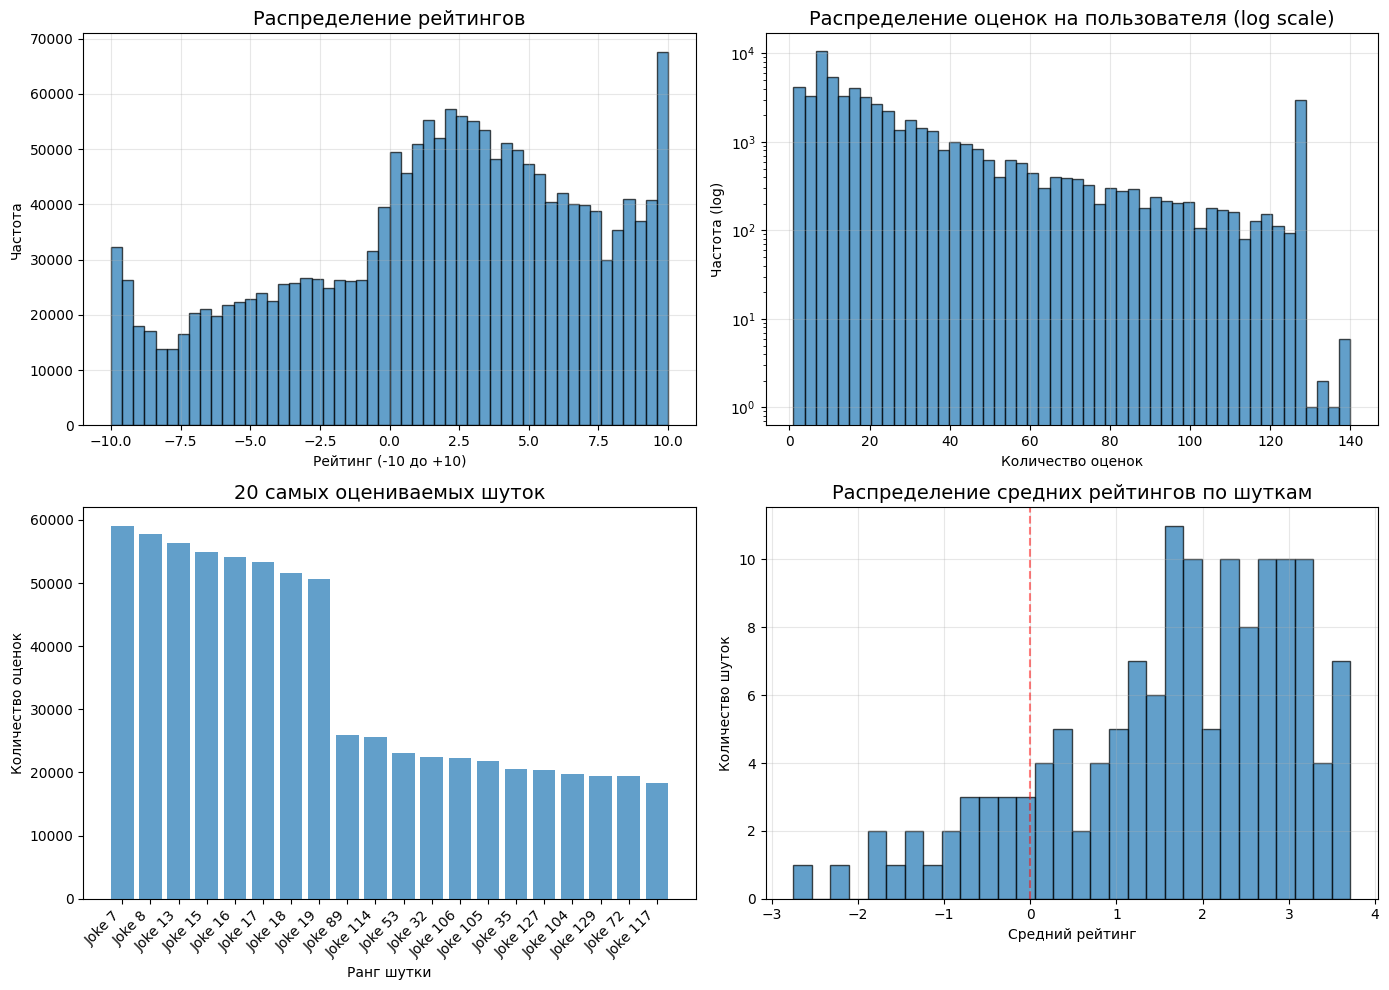

In [175]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))


axes[0, 0].hist(ratings_df['rating'], bins=50, edgecolor='black', alpha=0.7)
axes[0, 0].set_title('Распределение рейтингов', fontsize=14)
axes[0, 0].set_xlabel('Рейтинг (-10 до +10)')
axes[0, 0].set_ylabel('Частота')
axes[0, 0].grid(True, alpha=0.3)


axes[0, 1].hist(ratings_per_user, bins=50, edgecolor='black', alpha=0.7, log=True)
axes[0, 1].set_title('Распределение оценок на пользователя (log scale)', fontsize=14)
axes[0, 1].set_xlabel('Количество оценок')
axes[0, 1].set_ylabel('Частота (log)')
axes[0, 1].grid(True, alpha=0.3)


joke_popularity = ratings_df.groupby('jokeId').size().sort_values(ascending=False)
top_20_jokes = joke_popularity.head(20)
axes[1, 0].bar(range(len(top_20_jokes)), top_20_jokes.values, alpha=0.7)
axes[1, 0].set_title('20 самых оцениваемых шуток', fontsize=14)
axes[1, 0].set_xlabel('Ранг шутки')
axes[1, 0].set_ylabel('Количество оценок')
axes[1, 0].set_xticks(range(len(top_20_jokes)))
axes[1, 0].set_xticklabels([f"Joke {i}" for i in top_20_jokes.index], rotation=45, ha='right')


avg_rating_per_joke = ratings_df.groupby('jokeId')['rating'].mean().sort_values(ascending=False)
axes[1, 1].hist(avg_rating_per_joke, bins=30, edgecolor='black', alpha=0.7)
axes[1, 1].set_title('Распределение средних рейтингов по шуткам', fontsize=14)
axes[1, 1].set_xlabel('Средний рейтинг')
axes[1, 1].set_ylabel('Количество шуток')
axes[1, 1].axvline(x=0, color='red', linestyle='--', alpha=0.5)
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

График распределения рейтингов:  
- Распределение отличное от нормального с пиком на ~2.5  
- Из графика видно, что пользователи чаще ставят высокие оценки  
- Пользователи чаще ставят средние оценки (ближе к положительным), а также самые высокие и самые низкие  
  
График распределения оценок на пользователя  
- Из графика можно сделать вывод, что пользователей оставляющих оценки активно меньше  
- Пользователей, которые оценили все 140 шуток крайне мало  

График распределения средних рейтингов по шуткам:  
- Большинство шуток имеет рейтинг от +1.5 до +3.5

In [176]:
print("\nСоздание отображений (mappings)")

unique_users = ratings_sample['userId'].unique()
unique_jokes = ratings_sample['jokeId'].unique()


user_to_index = {uid: idx for idx, uid in enumerate(unique_users)}
joke_to_index = {jid: idx for idx, jid in enumerate(unique_jokes)}


index_to_user = {idx: uid for uid, idx in user_to_index.items()}
index_to_joke = {idx: jid for jid, idx in joke_to_index.items()}

print(f"- Уникальных пользователей в выборке: {len(unique_users):,}")
print(f"- Уникальных шуток в выборке: {len(unique_jokes):,}")


ratings_sample['user_idx'] = ratings_sample['userId'].map(user_to_index)
ratings_sample['joke_idx'] = ratings_sample['jokeId'].map(joke_to_index)


print(f"- Проверка маппинга (пропуски):")
print(f"     user_idx NaN: {ratings_sample['user_idx'].isna().sum()}")
print(f"     joke_idx NaN: {ratings_sample['joke_idx'].isna().sum()}")


Создание отображений (mappings)
- Уникальных пользователей в выборке: 8,457
- Уникальных шуток в выборке: 137
- Проверка маппинга (пропуски):
     user_idx NaN: 0
     joke_idx NaN: 0


In [177]:
print("\nНормализация рейтингов")

min_rating = -10.0
max_rating = 10.0


ratings_sample['rating_norm'] = ratings_sample['rating'] / max_rating


print(f"- Диапазон исходных рейтингов: [{min_rating}, {max_rating}]")
print(f"- Диапазон нормализованных: [{ratings_sample['rating_norm'].min():.2f}, {ratings_sample['rating_norm'].max():.2f}]")
print(f"- Среднее нормализованных: {ratings_sample['rating_norm'].mean():.4f}")



Нормализация рейтингов
- Диапазон исходных рейтингов: [-10.0, 10.0]
- Диапазон нормализованных: [-1.00, 1.00]
- Среднее нормализованных: 0.1687


In [178]:
print("\nРазделение на train/val/test")

from sklearn.model_selection import train_test_split

train_val_df, test_df = train_test_split(
    ratings_sample, 
    test_size=0.2,      
    random_state=42,    
    stratify=None 
)


train_df, val_df = train_test_split(
    train_val_df,
    test_size=0.125,
    random_state=42
)

print(f"   - Обучающая выборка: {len(train_df):,} записей ({len(train_df)/len(ratings_sample)*100:.1f}%)")
print(f"   - Валидационная выборка: {len(val_df):,} записей ({len(val_df)/len(ratings_sample)*100:.1f}%)")
print(f"   - Тестовая выборка: {len(test_df):,} записей ({len(test_df)/len(ratings_sample)*100:.1f}%)")


users_in_train = set(train_df['user_idx'].unique())
users_in_val = set(val_df['user_idx'].unique())
users_in_test = set(test_df['user_idx'].unique())

jokes_in_train = set(train_df['joke_idx'].unique())
jokes_in_val = set(val_df['joke_idx'].unique())
jokes_in_test = set(test_df['joke_idx'].unique())

print(f"\n   - Пользователи только в валидации: {len(users_in_val - users_in_train)}")
print(f"   - Пользователи только в тесте: {len(users_in_test - users_in_train)}")
print(f"   - Шутки только в валидации: {len(jokes_in_val - jokes_in_train)}")
print(f"   - Шутки только в тесте: {len(jokes_in_test - jokes_in_train)}")



Разделение на train/val/test
   - Обучающая выборка: 7,000 записей (70.0%)
   - Валидационная выборка: 1,000 записей (10.0%)
   - Тестовая выборка: 2,000 записей (20.0%)

   - Пользователи только в валидации: 759
   - Пользователи только в тесте: 1526
   - Шутки только в валидации: 1
   - Шутки только в тесте: 1


В валидационной и тестовой выборках присутствуют пользователи, которых нет в обучающей выборке. Это хорошо для оценки реалистичности модели. В реальной системе постоянно появляются новые пользователи, и модель должна уметь давать рекомендации даже без истории.  
- Почти все шутки (138 из 140) присутствуют во всех выборках  
- Это хорошо для оценки качества предсказаний - модель видела все шутки во время обучения  
- 2 "новые" шутки в валидации и тесте позволяют оценить способность модели к рекомендации нового контента  

In [179]:
print("\nСоздание PyTorch Dataset и DataLoader...")

import torch
from torch.utils.data import Dataset, DataLoader

class JokesDataset(Dataset):
    def __init__(self, df):
        self.users = torch.tensor(df['user_idx'].values, dtype=torch.long)
        self.jokes = torch.tensor(df['joke_idx'].values, dtype=torch.long)
        self.ratings = torch.tensor(df['rating_norm'].values, dtype=torch.float32).view(-1, 1)
        
    def __len__(self):
        return len(self.ratings)
    
    def __getitem__(self, idx):
        return self.users[idx], self.jokes[idx], self.ratings[idx]


train_dataset = JokesDataset(train_df)
val_dataset = JokesDataset(val_df)
test_dataset = JokesDataset(test_df)

print(f"   - Размер train_dataset: {len(train_dataset)}")
print(f"   - Размер val_dataset: {len(val_dataset)}")
print(f"   - Размер test_dataset: {len(test_dataset)}")


BATCH_SIZE = 256
NUM_WORKERS = 0


train_loader = DataLoader(
    train_dataset, 
    batch_size=BATCH_SIZE, 
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True if torch.cuda.is_available() else False
)

val_loader = DataLoader(
    val_dataset, 
    batch_size=BATCH_SIZE, 
    shuffle=False,   
    num_workers=NUM_WORKERS,
    pin_memory=True if torch.cuda.is_available() else False
)

test_loader = DataLoader(
    test_dataset, 
    batch_size=BATCH_SIZE, 
    shuffle=False,     
    num_workers=NUM_WORKERS,
    pin_memory=True if torch.cuda.is_available() else False
)

print(f"   - Количество батчей в train_loader: {len(train_loader)}")
print(f"   - Количество батчей в val_loader: {len(val_loader)}")
print(f"   - Количество батчей в test_loader: {len(test_loader)}")



Создание PyTorch Dataset и DataLoader...
   - Размер train_dataset: 7000
   - Размер val_dataset: 1000
   - Размер test_dataset: 2000
   - Количество батчей в train_loader: 28
   - Количество батчей в val_loader: 4
   - Количество батчей в test_loader: 8


За 1 эпоху обучения:
- Прямых проходов (forward): 28
- Обновлений весов (backward): 28
- Просмотрено примеров: 7 000
- Пропускная способность: ~28 батчей * 256 = 7 168 примеров/эпоху

In [180]:
print("\nПроверка итоговых данных")

sample_users, sample_jokes, sample_ratings = next(iter(train_loader))

print(f"   - Формат входных тензоров:")
print(f"     users: {sample_users.shape} (должен быть [batch_size])")
print(f"     jokes: {sample_jokes.shape} (должен быть [batch_size])")
print(f"     ratings: {sample_ratings.shape} (должен быть [batch_size, 1])")

print(f"\n   - Типы данных:")
print(f"     users: {sample_users.dtype} (torch.long)")
print(f"     jokes: {sample_jokes.dtype} (torch.long)")
print(f"     ratings: {sample_ratings.dtype} (torch.float32)")

print(f"\n   - Диапазоны в батче:")
print(f"     users: [{sample_users.min()}, {sample_users.max()}]")
print(f"     jokes: [{sample_jokes.min()}, {sample_jokes.max()}]")
print(f"     ratings: [{sample_ratings.min():.2f}, {sample_ratings.max():.2f}]")


print("\n")


model_metadata = {
    'num_users': len(unique_users),
    'num_jokes': len(unique_jokes),
    'min_rating': min_rating,
    'max_rating': max_rating,
    'user_to_index': user_to_index,
    'joke_to_index': joke_to_index,
    'index_to_user': index_to_user,
    'index_to_joke': index_to_joke,
    'batch_size': BATCH_SIZE
}

import pickle
with open('model_metadata.pkl', 'wb') as f:
    pickle.dump(model_metadata, f)

print("Метаданные сохранены в 'model_metadata.pkl'")
print("\nДанные полностью подготовлены к обучению!")


Проверка итоговых данных
   - Формат входных тензоров:
     users: torch.Size([256]) (должен быть [batch_size])
     jokes: torch.Size([256]) (должен быть [batch_size])
     ratings: torch.Size([256, 1]) (должен быть [batch_size, 1])

   - Типы данных:
     users: torch.int64 (torch.long)
     jokes: torch.int64 (torch.long)
     ratings: torch.float32 (torch.float32)

   - Диапазоны в батче:
     users: [9, 8419]
     jokes: [0, 133]
     ratings: [-0.98, 1.00]


Метаданные сохранены в 'model_metadata.pkl'

Данные полностью подготовлены к обучению!


In [181]:
#device = torch.device("cuda" if torch.cuda.is_available() else "gpu")
print(f"Используем устройство: {device}")



with open('model_metadata.pkl', 'rb') as f:
    model_metadata = pickle.load(f)

NUM_USERS = model_metadata['num_users']
NUM_JOKES = model_metadata['num_jokes']
MIN_RATING = model_metadata['min_rating']
MAX_RATING = model_metadata['max_rating']

print(f"Количество пользователей: {NUM_USERS}")
print(f"Количество шуток: {NUM_JOKES}")
print(f"Диапазон рейтингов: [{MIN_RATING}, {MAX_RATING}]")

Используем устройство: cpu
Количество пользователей: 8457
Количество шуток: 137
Диапазон рейтингов: [-10.0, 10.0]


In [182]:
print("Определение архитектуры модели")
print("\n")

class JokeRecommender(nn.Module):

    def __init__(self, num_users, num_jokes, embedding_dim=50, hidden_dims=[128, 64]):

        super(JokeRecommender, self).__init__()
        
        self.user_embedding = nn.Embedding(num_users, embedding_dim)
        self.joke_embedding = nn.Embedding(num_jokes, embedding_dim)
        
        nn.init.xavier_uniform_(self.user_embedding.weight)
        nn.init.xavier_uniform_(self.joke_embedding.weight)
        
        layers = []
        input_dim = embedding_dim * 2
        
        for hidden_dim in hidden_dims:
            layers.extend([
                nn.Linear(input_dim, hidden_dim),
                nn.BatchNorm1d(hidden_dim),
                nn.ReLU(),
                nn.Dropout(0.2)
            ])
            input_dim = hidden_dim
        
        layers.append(nn.Linear(input_dim, 1))
        
        self.layers = nn.Sequential(*layers)
        
        self.train_losses = []
        self.val_losses = []
        
    def forward(self, user_ids, joke_ids):

        user_embedded = self.user_embedding(user_ids)
        joke_embedded = self.joke_embedding(joke_ids)
        
        combined = torch.cat([user_embedded, joke_embedded], dim=1)
        
        output = self.layers(combined)
        
        return output


EMBEDDING_DIM = 50
HIDDEN_DIMS = [128, 64, 32]

model = JokeRecommender(
    num_users=NUM_USERS, 
    num_jokes=NUM_JOKES, 
    embedding_dim=EMBEDDING_DIM, 
    hidden_dims=HIDDEN_DIMS
).to(device)

print(f"Модель создана:")
print(f"  - Размерность эмбеддингов: {EMBEDDING_DIM}")
print(f"  - Скрытые слои: {HIDDEN_DIMS}")
print(f"  - Параметров модели: {sum(p.numel() for p in model.parameters()):,}")

Определение архитектуры модели


Модель создана:
  - Размерность эмбеддингов: 50
  - Скрытые слои: [128, 64, 32]
  - Параметров модели: 453,445


Модель построена на основе эмбеддингов пользователей и объектов размерности 50, которые после конкатенации пропускаются через три полносвязных слоя с убывающей размерностью (128-64-32) и выходной линейный слой.

In [183]:
print("Настройка обучения")
print("\n")

criterion = nn.MSELoss()

optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)

scheduler = ReduceLROnPlateau(
    optimizer, 
    mode='min',
    factor=0.5,
    patience=5,
)

print(f"Функция потерь: MSELoss")
print(f"Оптимизатор: Adam (lr=0.001, weight_decay=1e-5)")
print(f"Планировщик: ReduceLROnPlateau (factor=0.5, patience=5)")

Настройка обучения


Функция потерь: MSELoss
Оптимизатор: Adam (lr=0.001, weight_decay=1e-5)
Планировщик: ReduceLROnPlateau (factor=0.5, patience=5)


Обучение модели будет проводиться с использованием MSE (среднеквадратичной ошибки) в качестве функции потерь, оптимизатора Adam с начальной скоростью обучения 0.001 и L2-регуляризацией 1^(-5), а также планировщика ReduceLROnPlateau, уменьшающего скорость обучения в 2 раза при отсутствии улучшений на валидации в течение 5 эпох.

In [184]:
def train_epoch(model, train_loader, criterion, optimizer, device):
    model.train()
    total_loss = 0
    num_batches = 0
    
    for users, jokes, ratings in tqdm(train_loader, desc="Обучение", leave=False):
        users = users.to(device)
        jokes = jokes.to(device)
        ratings = ratings.to(device)
        
        optimizer.zero_grad()
        
        predictions = model(users, jokes)
        
        loss = criterion(predictions, ratings)
        
        loss.backward()
        
        optimizer.step()
        
        total_loss += loss.item()
        num_batches += 1
    
    return total_loss / num_batches

def validate(model, val_loader, criterion, device):
    model.eval()
    total_loss = 0
    num_batches = 0
    
    with torch.no_grad():
        for users, jokes, ratings in tqdm(val_loader, desc="Валидация", leave=False):
            users = users.to(device)
            jokes = jokes.to(device)
            ratings = ratings.to(device)
            
            predictions = model(users, jokes)
            loss = criterion(predictions, ratings)
            
            total_loss += loss.item()
            num_batches += 1
    
    return total_loss / num_batches

Функция train_epoch реализует полный цикл обучения на одной эпохе с прямым и обратным проходами, обновлением весов и накоплением потерь, а validate выполняет оценку модели на валидационной выборке без вычисления градиентов.

In [185]:
print("Начало обучения")
print("\n")

NUM_EPOCHS = 50
best_val_loss = float('inf')
patience_counter = 0
early_stop_patience = 10 

for epoch in range(NUM_EPOCHS):
    print(f"\n--- Эпоха {epoch+1}/{NUM_EPOCHS} ---")
    
    train_loss = train_epoch(model, train_loader, criterion, optimizer, device)
    
    val_loss = validate(model, val_loader, criterion, device)
    
    model.train_losses.append(train_loss)
    model.val_losses.append(val_loss)
    
    old_lr = optimizer.param_groups[0]['lr']
    scheduler.step(val_loss)
    new_lr = optimizer.param_groups[0]['lr']
    
    if old_lr != new_lr:
        print(f"  ✓ Learning rate уменьшен с {old_lr:.6f} до {new_lr:.6f}")
    
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        torch.save(model.state_dict(), 'best_model.pth')
        print(f"  Новый лучший результат! (val_loss: {val_loss:.6f}) Сохранено в 'best_model.pth'")
    else:
        patience_counter += 1
        if patience_counter >= early_stop_patience:
            print(f"\nРанняя остановка на эпохе {epoch+1} (нет улучшений {early_stop_patience} эпох)")
            break
    
    current_lr = optimizer.param_groups[0]['lr']
    print(f"  Train Loss: {train_loss:.6f}")
    print(f"  Val Loss: {val_loss:.6f}")
    print(f"  LR: {current_lr:.6f}")

Начало обучения



--- Эпоха 1/50 ---


  Новый лучший результат! (val_loss: 0.277840) Сохранено в 'best_model.pth'
  Train Loss: 0.346436
  Val Loss: 0.277840
  LR: 0.001000

--- Эпоха 2/50 ---


  Новый лучший результат! (val_loss: 0.268337) Сохранено в 'best_model.pth'
  Train Loss: 0.286626
  Val Loss: 0.268337
  LR: 0.001000

--- Эпоха 3/50 ---


  Новый лучший результат! (val_loss: 0.267717) Сохранено в 'best_model.pth'
  Train Loss: 0.263822
  Val Loss: 0.267717
  LR: 0.001000

--- Эпоха 4/50 ---


  Train Loss: 0.245312
  Val Loss: 0.268900
  LR: 0.001000

--- Эпоха 5/50 ---


...

  ✓ Learning rate уменьшен с 0.001000 до 0.000500
  Train Loss: 0.059081
  Val Loss: 0.287792
  LR: 0.000500

--- Эпоха 10/50 ---


  Train Loss: 0.049769
  Val Loss: 0.284732
  LR: 0.000500

--- Эпоха 11/50 ---


  Train Loss: 0.043722
  Val Loss: 0.284690
  LR: 0.000500

--- Эпоха 12/50 ---


  Train Loss: 0.040803
  Val Loss: 0.288043
  LR: 0.000500

--- Эпоха 13/50 ---



Ранняя остановка на эпохе 13 (нет улучшений 10 эпох)


In [186]:
print("Оценка модели")
print("\n")

model.load_state_dict(torch.load('best_model.pth'))
model.eval()

all_predictions = []
all_ratings = []

with torch.no_grad():
    for users, jokes, ratings in tqdm(test_loader, desc="Тестирование"):
        users = users.to(device)
        jokes = jokes.to(device)
        
        predictions = model(users, jokes)
        
        all_predictions.extend(predictions.cpu().numpy().flatten())
        all_ratings.extend(ratings.numpy().flatten())

all_predictions = np.array(all_predictions)
all_ratings = np.array(all_ratings)

test_mse = mean_squared_error(all_ratings, all_predictions)
test_mae = mean_absolute_error(all_ratings, all_predictions)
test_rmse = np.sqrt(test_mse)

predictions_original = all_predictions * MAX_RATING
ratings_original = all_ratings * MAX_RATING

test_mse_original = mean_squared_error(ratings_original, predictions_original)
test_mae_original = mean_absolute_error(ratings_original, predictions_original)
test_rmse_original = np.sqrt(test_mse_original)

print(f"\nМетрики на тестовой выборке (нормализованные [-1, 1]):")
print(f"  MSE:  {test_mse:.6f}")
print(f"  RMSE: {test_rmse:.6f}")
print(f"  MAE:  {test_mae:.6f}")

print(f"\nМетрики на тестовой выборке (оригинальный масштаб [-10, 10]):")
print(f"  MSE:  {test_mse_original:.4f}")
print(f"  RMSE: {test_rmse_original:.4f}")
print(f"  MAE:  {test_mae_original:.4f}")

Оценка модели




Тестирование: 100%|██████████| 8/8 [00:00<00:00, 137.13it/s]


Метрики на тестовой выборке (нормализованные [-1, 1]):
  MSE:  0.259426
  RMSE: 0.509339
  MAE:  0.416309

Метрики на тестовой выборке (оригинальный масштаб [-10, 10]):
  MSE:  25.9426
  RMSE: 5.0934
  MAE:  4.1631


Результаты средние: в целом модель ошибается на 4.17 - это лучше чем случайное угадывание, но на уровне среднего.  
Это может быть связано со следующим:  
- после сокращения выборки до 10000 данных стало мало;  
- мало эпох (обучается за 2-3 эпохи);  
- в тесте много новых пользователей.  
  
Модель была протестирована с сохранением 500.000 строк - качество модели заметно улучшилось: MAE ~ 3,4 и модель стала больше попадать в истинный рейтинг, но все равно качество не стало хорошим, оно стало лучше среднего. А также график ошибок стал иметь распределение практически идеально соответствующее нормальному и меньший разброс.   

C:\Users\roman\AppData\Local\Temp\ipykernel_9472\3738779865.py:22: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([predictions_original, ratings_original], labels=['Предсказания', 'Истинные'])


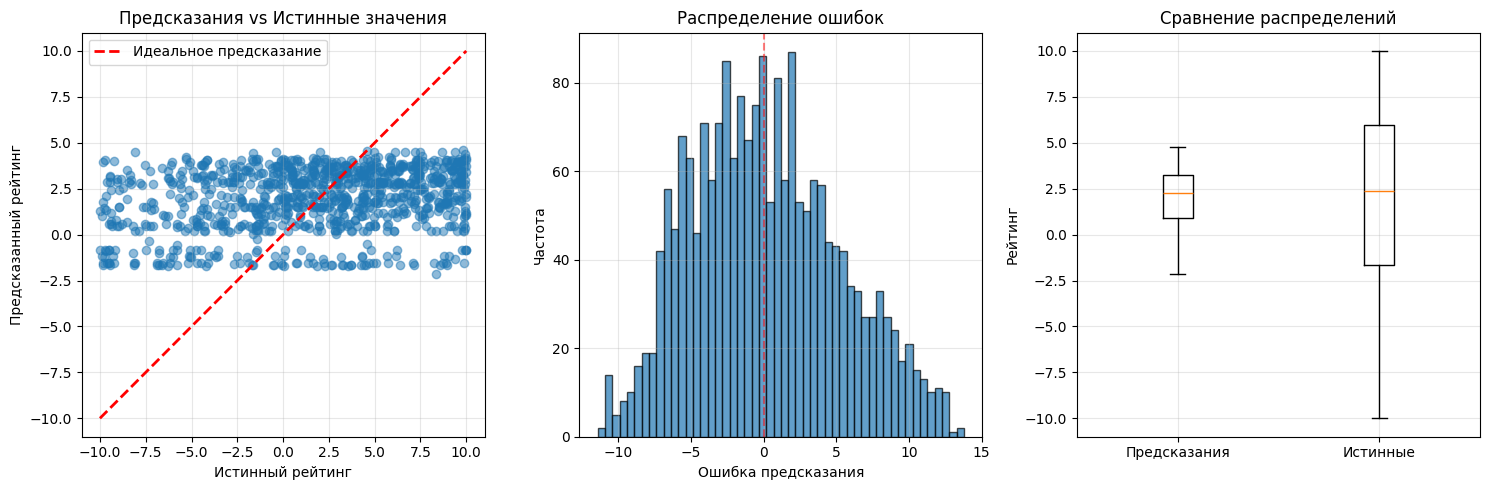

In [187]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.scatter(ratings_original[:1000], predictions_original[:1000], alpha=0.5)
plt.plot([-10, 10], [-10, 10], 'r--', linewidth=2, label='Идеальное предсказание')
plt.xlabel('Истинный рейтинг')
plt.ylabel('Предсказанный рейтинг')
plt.title('Предсказания vs Истинные значения')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 3, 2)
errors = predictions_original - ratings_original
plt.hist(errors, bins=50, edgecolor='black', alpha=0.7)
plt.xlabel('Ошибка предсказания')
plt.ylabel('Частота')
plt.title('Распределение ошибок')
plt.axvline(x=0, color='r', linestyle='--', alpha=0.5)
plt.grid(True, alpha=0.3)

plt.subplot(1, 3, 3)
plt.boxplot([predictions_original, ratings_original], labels=['Предсказания', 'Истинные'])
plt.ylabel('Рейтинг')
plt.title('Сравнение распределений')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Предсказания VS истинные значения:  

- Точки образуют "полосу" вытянутую вдоль оси истинных предсказаний, что показывает, что модель сильно ошибается в крайних значениях
- Сильный разброс - точки далеко от линии  
- Много предсказаний за пределами диапазона [-10, 10]  
- Модель плохо предсказывает крайние значения рейтинга (самые низкие и самые высокие оценки)  
  
Распределение ошибок:  

- Распределение нормальное, что хорошо (симметричное)  
- Большой разброс - плохо, большие ошибки
  
Сравнение распределений:  
- Медианы совпадают (~2.5) - хорошо
- Разброс предсказаний больше, чем у реальных данных  

In [188]:
print("Персонализированные рекомендации шуток")
print("\n")

def get_top_n_recommendations(model, user_idx, joke_indices, rated_jokes=None, n=10, device='cpu'):
    model.eval()
    
    if rated_jokes is not None:
        candidate_jokes = [j for j in joke_indices if j not in rated_jokes]
    else:
        candidate_jokes = joke_indices
    
    batch_size = 1024
    predictions = []
    
    with torch.no_grad():
        for i in range(0, len(candidate_jokes), batch_size):
            batch_jokes = candidate_jokes[i:i+batch_size]
            users = torch.tensor([user_idx] * len(batch_jokes), dtype=torch.long).to(device)
            jokes = torch.tensor(batch_jokes, dtype=torch.long).to(device)
            
            batch_pred = model(users, jokes).cpu().numpy().flatten()
            predictions.extend(batch_pred)
    
    predictions = np.array(predictions) * MAX_RATING
    
    top_indices = np.argsort(predictions)[::-1][:n]
    
    recommendations = []
    for idx in top_indices:
        joke_idx = candidate_jokes[idx]
        original_joke_id = model_metadata['index_to_joke'][joke_idx]
        pred_rating = predictions[idx]
        
        recommendations.append({
            'rank': len(recommendations) + 1,
            'joke_id': original_joke_id,
            'predicted_rating': pred_rating
        })
    
    return recommendations

def get_joke_text(joke_id):
    try:
        joke_row = jokes_df[jokes_df['jokeId'] == joke_id]
        if not joke_row.empty:
            return joke_row.iloc[0]['jokeText']
    except:
        pass
    return f"[Текст шутки #{joke_id} не найден]"

print("\n1. Случайный выбор пользователя")
print("\n")

random_user_idx = np.random.choice(test_df['user_idx'].unique())
original_user_id = model_metadata['index_to_user'][random_user_idx]

print(f"Выбран пользователь:")
print(f"  - Индекс в модели: {random_user_idx}")
print(f"  - Оригинальный ID: {original_user_id}")

print("\n2. История пользователя\n")

user_history = pd.concat([
    train_df[train_df['user_idx'] == random_user_idx],
    val_df[val_df['user_idx'] == random_user_idx],
    test_df[test_df['user_idx'] == random_user_idx]
])

print(f"Всего оценено шуток: {len(user_history)}")

if len(user_history) > 0:
    user_ratings = user_history['rating'].values * MAX_RATING
    print(f"Средняя оценка: {user_ratings.mean():.2f}")
    print(f"Разброс оценок: от {user_ratings.min():.2f} до {user_ratings.max():.2f}")
    
    print("\nЛюбимые шутки пользователя:")
    favorite = user_history.nlargest(3, 'rating')
    for _, row in favorite.iterrows():
        joke_id = model_metadata['index_to_joke'][row['joke_idx']]
        rating = row['rating'] * MAX_RATING
        joke_text = get_joke_text(joke_id)
        print(f"    {joke_id} (рейтинг: {rating:.2f})")
        print(f"    {joke_text[:100]}..." if len(joke_text) > 100 else f"    {joke_text}")
        print()
else:
    print("  Новый пользователь без истории оценок")

Персонализированные рекомендации шуток



1. Случайный выбор пользователя


Выбран пользователь:
  - Индекс в модели: 927
  - Оригинальный ID: 14345

2. История пользователя

Всего оценено шуток: 3
Средняя оценка: 54.48
Разброс оценок: от -18.75 до 97.81

Любимые шутки пользователя:
    69 (рейтинг: 97.81)
    This guys wife asks, "Honey if I died would you remarry?" and he replies,
"Well, after a considerabl...

    87 (рейтинг: 84.38)
    A man, recently completing a routine physical examination receives a
phone call from his doctor.  Th...

    18 (рейтинг: -18.75)
    A dog walks into Western Union and asks the clerk to send a telegram. He fills out a form on which h...



In [189]:
print("\n3. Подбор 5 рекомендаций\n")

all_joke_indices = list(model_metadata['joke_to_index'].values())

rated_jokes = set(user_history['joke_idx'].values) if len(user_history) > 0 else None

recommendations = get_top_n_recommendations(
    model=model,
    user_idx=random_user_idx,
    joke_indices=all_joke_indices,
    rated_jokes=rated_jokes,
    n=5,
    device=device
)

for rec in recommendations:
    joke_text = get_joke_text(rec['joke_id'])
    print(f"\n{rec['rank']}. ШУТКА #{rec['joke_id']}")
    print(f"   Предсказанный рейтинг: {rec['predicted_rating']:.2f}")


3. Подбор 5 рекомендаций


1. ШУТКА #99
   Предсказанный рейтинг: 4.86

2. ШУТКА #126
   Предсказанный рейтинг: 4.75

3. ШУТКА #72
   Предсказанный рейтинг: 4.60

4. ШУТКА #104
   Предсказанный рейтинг: 4.14

5. ШУТКА #76
   Предсказанный рейтинг: 4.13


In [190]:
print("\n4. Статистика рекомендаций\n")

pred_ratings = [rec['predicted_rating'] for rec in recommendations]
print(f"Средний предсказанный рейтинг: {np.mean(pred_ratings):.2f}")
print(f"Лучшая рекомендация: {max(pred_ratings):.2f}")
print(f"Худшая в топ-5: {min(pred_ratings):.2f}")

if len(user_history) > 0:
    avg_history = user_ratings.mean()
    avg_rec = np.mean(pred_ratings)
    print(f"\nСравнение с историей пользователя:")
    print(f" - Средняя оценка в истории: {avg_history:.2f}")
    print(f" - Средняя в рекомендациях: {avg_rec:.2f}")
    print(f" - Разница: {avg_rec - avg_history:+.2f}")


4. Статистика рекомендаций

Средний предсказанный рейтинг: 4.50
Лучшая рекомендация: 4.86
Худшая в топ-5: 4.13

Сравнение с историей пользователя:
 - Средняя оценка в истории: 54.48
 - Средняя в рекомендациях: 4.50
 - Разница: -49.98


Общий вывод по модели:
- Модель работает относительно корректно: ошибки около 0, распределение ошибок нормальное, основной диапазон модель уловила;  
- Но качество модели около среднего:  
-- В данных слишком много средних оценок, на которых обучилась модель, при этом плохо предсказывая крайние значения;  
-- 10000 строк данных мало для достаточного обучения.  